# Aula 18

# Métodos de ajuste de hiperparâmetros e regularização

### Eduardo Lobo Lustosa Cabral

## 1. Objetivo

Apresentar como realizar o ajuste de hiper parâmetros e a regularização de uma RNA.

### Importar bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.__version__

'2.19.0'

## 2. Conjunto de dados

Vamos utlizar o conjunto de dados CIFAR10, que consiste em classificação multiclasse de imagens

In [ ]:
# Carregar Dados CIFAR
from tensorflow.keras.datasets import cifar10

# load dataset
(Xtrain, Ytrain), (Xtest, Ytest) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Normalização das imagens
x_train = (Xtrain - 127.5)/127.5
x_test = (Xtest - 127.5)/127.5

# Codificação one-hot das saídas
y_train_hot = tf.keras.utils.to_categorical(Ytrain, 10)
y_test_hot = tf.keras.utils.to_categorical(Ytest, 10)

print('Dimensão dos dados de entrada:', x_train.shape, x_test.shape)
print('Maximos e mínimos treinamento:', np.min(x_train), np.mean(x_train), np.max(x_train))
print('Maximos e mínimos teste:', np.min(x_test), np.mean(x_test), np.max(x_test))
print('exemplos de entradas:', x_train[0,16])
print('Exemplos de saídas:', y_train_hot.shape, y_test_hot.shape, '\n', Ytrain[:5].T, '\n', y_train_hot[:5])

Dimensão dos dados de entrada: (50000, 32, 32, 3) (10000, 32, 32, 3)
Maximos e mínimos treinamento: -1.0 -0.05327399902982031 1.0
Maximos e mínimos teste: -1.0 -0.046830158803104496 1.0
exemplos de entradas: [[ 0.16862745 -0.09803922 -0.38039216]
 [ 0.12156863 -0.25490196 -0.61568627]
 [ 0.12941176 -0.23921569 -0.6       ]
 [ 0.18431373 -0.22352941 -0.6       ]
 [ 0.03529412 -0.31764706 -0.61568627]
 [-0.49803922 -0.68627451 -0.83529412]
 [-0.34117647 -0.5372549  -0.67843137]
 [-0.12156863 -0.45882353 -0.70980392]
 [ 0.27843137 -0.05098039 -0.41176471]
 [ 0.74901961  0.6         0.30196078]
 [ 0.61568627  0.42745098  0.23137255]
 [ 0.1372549  -0.29411765 -0.56078431]
 [ 0.5372549   0.04313725 -0.34117647]
 [ 0.6         0.23137255 -0.1372549 ]
 [ 0.7254902   0.4745098   0.22352941]
 [ 0.90588235  0.77254902  0.63137255]
 [ 0.92156863  0.85882353  0.77254902]
 [ 0.8745098   0.82745098  0.68627451]
 [ 0.83529412  0.75686275  0.57647059]
 [ 0.81176471  0.70196078  0.50588235]
 [ 0.5294117

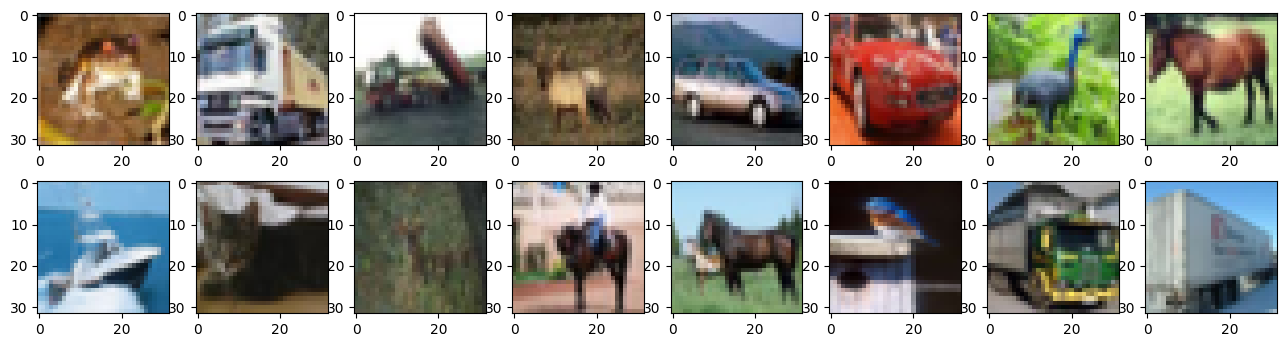

In [ ]:
fig, axs = plt.subplots(2, 8, figsize=(16, 4))
index = 0
for i in range(2):
    for j in range(8):
        axs[i,j].imshow(Xtrain[index], cmap='gray')
        index += 1
plt.show()

## 3. Rede sem regularização


In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

rna = models.Sequential()
rna.add(layers.Flatten(input_shape=(32,32,3)))
rna.add(layers.Dense(64, activation='relu'))
rna.add(layers.Dense(10, activation='softmax'))

rna.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,322 (770.79 KB)

 Trainable params: 197,322 (770.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = optimizers.SGD(learning_rate=0.01, momentum=0.92, nesterov=True)
rna.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
historia = rna.fit(x_train, y_train_hot, epochs=100, batch_size=250, validation_data=(x_test, y_test_hot))

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3349 - loss: 1.8708 - val_accuracy: 0.4432 - val_loss: 1.5812
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4671 - loss: 1.5273 - val_accuracy: 0.4751 - val_loss: 1.5060
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4977 - loss: 1.4421 - val_accuracy: 0.4836 - val_loss: 1.4715
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5164 - loss: 1.3926 - val_accuracy: 0.4935 - val_loss: 1.4461
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5349 - loss: 1.3419 - val_accuracy: 0.4996 - val_loss: 1.4390
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5487 - loss: 1.3049 - val_accuracy: 0.5021 - val_loss: 1.4277
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5586 - loss: 1.2720 - val_accuracy: 0.4999 - val_loss: 1.4340
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5663 - loss: 1.2512 - val_accu

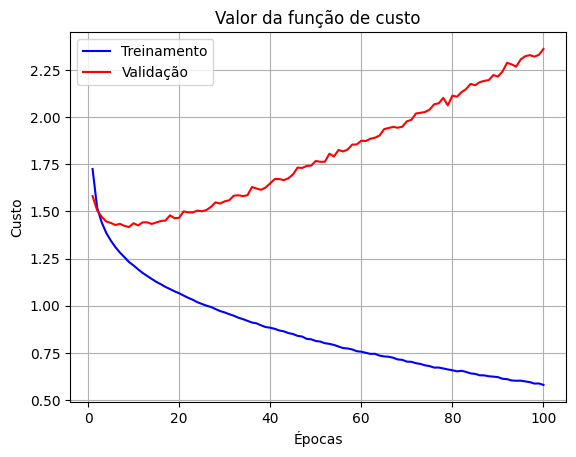

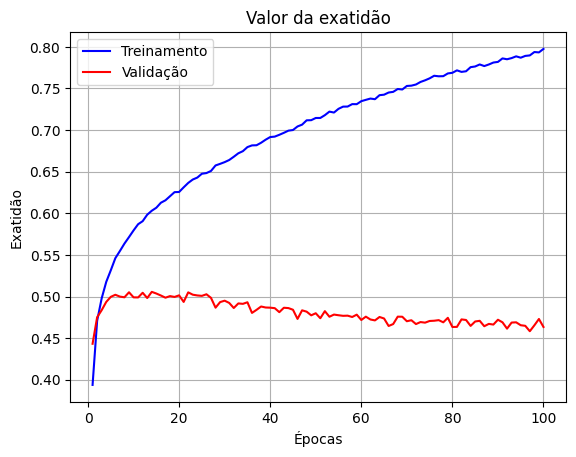

In [ ]:
# Salva custo,métrica e épocas em vetores
historia_dict = historia.history
custo = historia_dict['loss']
exatidao = historia_dict['accuracy']
custo_val = historia_dict['val_loss']
exatidao_val = historia_dict['val_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)

# Gráfico do custo
plt.plot(epocas, custo, 'b')
plt.plot(epocas, custo_val, 'r')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.legend(['Treinamento', 'Validação'])
plt.grid()
plt.show()

# Gráfico da exatidão
plt.plot(epocas, exatidao, 'b')
plt.plot(epocas, exatidao_val, 'r')
plt.title('Valor da exatidão')
plt.xlabel('Épocas')
plt.ylabel('Exatidão')
plt.legend(['Treinamento', 'Validação'])
plt.grid()
plt.show()

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

rna = models.Sequential()
rna.add(layers.Flatten(input_shape=(32,32,3)))
rna.add(layers.Dense(1024, activation='relu'))
rna.add(layers.Dense(512, activation='relu'))
rna.add(layers.Dense(256, activation='relu'))
rna.add(layers.Dense(128, activation='relu'))
rna.add(layers.Dense(10, activation='softmax'))

rna.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = optimizers.SGD(learning_rate=0.001, momentum=0.92, nesterov=True)
rna.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
historia = rna.fit(x_train, y_train_hot, epochs=100, batch_size=250, validation_data=(x_test, y_test_hot))

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2121 - loss: 2.1835 - val_accuracy: 0.3562 - val_loss: 1.8560
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3679 - loss: 1.7996 - val_accuracy: 0.4050 - val_loss: 1.6903
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4228 - loss: 1.6538 - val_accuracy: 0.4387 - val_loss: 1.6093
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4475 - loss: 1.5773 - val_accuracy: 0.4580 - val_loss: 1.5526
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4767 - loss: 1.5038 - val_accuracy: 0.4682 - val_loss: 1.5196
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4932 - loss: 1.4548 - val_accuracy: 0.4786 - val_loss: 1.4839
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5124 - loss: 1.4056 - val_accuracy: 0.4875 - val_loss: 1.4573
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5302 - loss: 1.3644 - val_acc

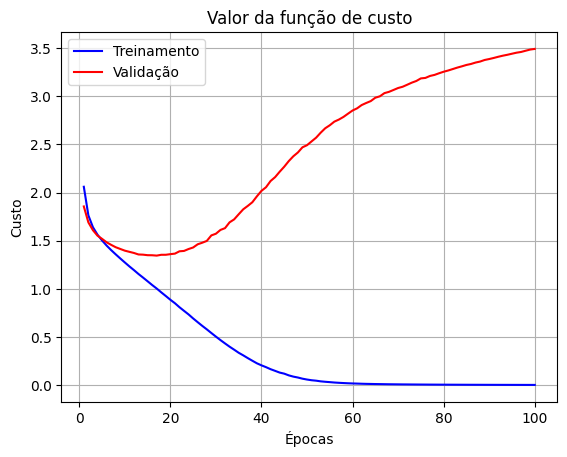

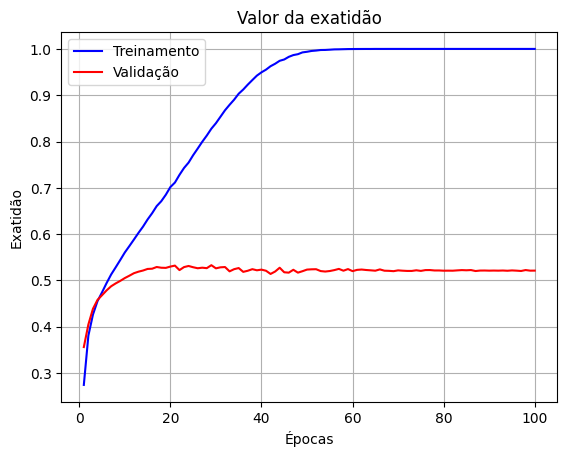

In [ ]:
# Salva custo,métrica e épocas em vetores
historia_dict = historia.history
custo = historia_dict['loss']
exatidao = historia_dict['accuracy']
custo_val = historia_dict['val_loss']
exatidao_val = historia_dict['val_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)
# Gráfico do custo
plt.plot(epocas, custo, 'b')
plt.plot(epocas, custo_val, 'r')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.legend(['Treinamento', 'Validação'])
plt.grid()
plt.show()

# Gráfico da exatidão
plt.plot(epocas, exatidao, 'b')
plt.plot(epocas, exatidao_val, 'r')
plt.title('Valor da exatidão')
plt.xlabel('Épocas')
plt.ylabel('Exatidão')
plt.legend(['Treinamento', 'Validação'])
plt.grid()
plt.show()

In [ ]:
cm_train = rna.evaluate(x_train, y_train_hot)
cm_test = rna.evaluate(x_test, y_test_hot)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 1.0000 - loss: 0.0030
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5277 - loss: 3.4746


## 4. Rede com regularização L2

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

rna = models.Sequential()
rna.add(layers.Flatten(input_shape=(32,32,3)))
rna.add(layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.012)))
rna.add(layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.012)))
rna.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.012)))
rna.add(layers.Dense(128, activation='relu'))
rna.add(layers.Dense(10, activation='softmax'))

rna.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = optimizers.SGD(learning_rate=0.001, momentum=0.92, nesterov=True)
rna.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
historia = rna.fit(x_train, y_train_hot, epochs=100, batch_size=250, validation_data=(x_test, y_test_hot))

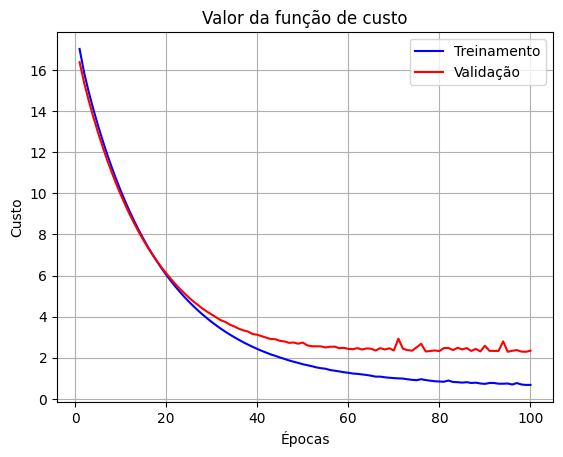

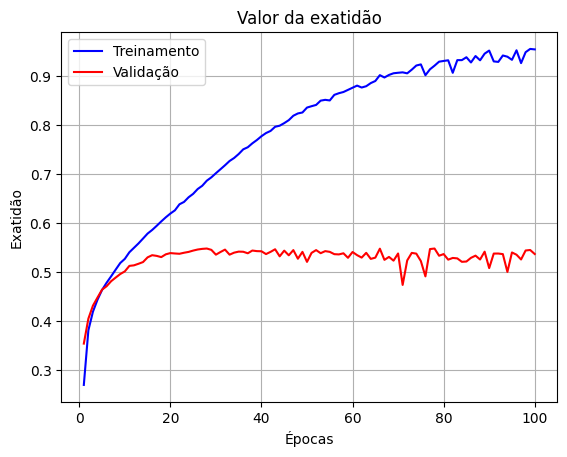

In [ ]:
# Salva custo,métrica e épocas em vetores
historia_dict = historia.history
custo = historia_dict['loss']
exatidao = historia_dict['accuracy']
custo_val = historia_dict['val_loss']
exatidao_val = historia_dict['val_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)
# Gráfico do custo
plt.plot(epocas, custo, 'b')
plt.plot(epocas, custo_val, 'r')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.legend(['Treinamento', 'Validação'])
plt.grid()
plt.show()

# Gráfico da exatidão
plt.plot(epocas, exatidao, 'b')
plt.plot(epocas, exatidao_val, 'r')
plt.title('Valor da exatidão')
plt.xlabel('Épocas')
plt.ylabel('Exatidão')
plt.legend(['Treinamento', 'Validação'])
plt.grid()
plt.show()

In [ ]:
cm_train = rna.evaluate(x_train, y_train_hot)
cm_test = rna.evaluate(x_test, y_test_hot)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9500 - loss: 0.6758
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5377 - loss: 2.3461


## 5. Rede com dropout

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

rna = models.Sequential()
rna.add(layers.Flatten(input_shape=(32,32,3)))
rna.add(layers.Dense(1024, activation='relu', kernel_constraint=tf.keras.constraints.MaxNorm(3.0)))
rna.add(layers.Dropout(0.4))
rna.add(layers.Dense(512, activation='relu', kernel_constraint=tf.keras.constraints.MaxNorm(3.0)))
rna.add(layers.Dropout(0.3))
rna.add(layers.Dense(256, activation='relu', kernel_constraint=tf.keras.constraints.MaxNorm(3.0)))
rna.add(layers.Dropout(0.2))
rna.add(layers.Dense(128, activation='relu', kernel_constraint=tf.keras.constraints.MaxNorm(3.0)))
rna.add(layers.Dropout(0.1))
rna.add(layers.Dense(10, activation='softmax'))

rna.summary()

In [ ]:
opt = optimizers.SGD(learning_rate=0.01, momentum=0.92, nesterov=True)
rna.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
historia = rna.fit(x_train, y_train_hot, batch_size=256, epochs=100, validation_data=(x_test, y_test_hot))

In [ ]:
# Salva custo,métrica e épocas em vetores
historia_dict = historia.history
custo = historia_dict['loss']
exatidao = historia_dict['accuracy']
custo_val = historia_dict['val_loss']
exatidao_val = historia_dict['val_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)

# Gráfico do custo
plt.plot(epocas, custo, 'b')
plt.plot(epocas, custo_val, 'r')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.grid()
plt.show()

# Gráfico da exatidão
plt.plot(epocas, exatidao, 'b')
plt.plot(epocas, exatidao_val, 'r')
plt.title('Valor da exatidão')
plt.xlabel('Épocas')
plt.ylabel('Exatidão')
plt.grid()
plt.show()

In [ ]:
cm_train = rna.evaluate(x_train, y_train_hot)
cm_test = rna.evaluate(x_test, y_test_hot)

## 6. Rede com normalização de batelada

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

rna = models.Sequential()
rna.add(layers.Flatten(input_shape=(32,32,3)))
rna.add(layers.Dense(1024, kernel_constraint=tf.keras.constraints.MaxNorm(3.0), use_bias=False))
rna.add(layers.BatchNormalization())
rna.add(layers.Activation('relu'))
rna.add(layers.Dropout(0.4))
rna.add(layers.Dense(512, kernel_constraint=tf.keras.constraints.MaxNorm(3.0), use_bias=False))
rna.add(layers.BatchNormalization())
rna.add(layers.Activation('relu'))
rna.add(layers.Dropout(0.3))
rna.add(layers.Dense(256, kernel_constraint=tf.keras.constraints.MaxNorm(3.0), use_bias=False))
rna.add(layers.BatchNormalization())
rna.add(layers.Activation('relu'))
rna.add(layers.Dropout(0.2))
rna.add(layers.Dense(128, kernel_constraint=tf.keras.constraints.MaxNorm(3.0), use_bias=False))
rna.add(layers.BatchNormalization())
rna.add(layers.Activation('relu'))
rna.add(layers.Dropout(0.1))
rna.add(layers.Dense(10, activation='softmax'))

rna.summary()

In [ ]:
opt = optimizers.SGD(learning_rate=0.01, momentum=0.92, nesterov=True)
rna.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
historia = rna.fit(x_train, y_train_hot, batch_size=256, epochs=100, validation_data=(x_test, y_test_hot))

In [ ]:
# Salva custo,métrica e épocas em vetores
historia_dict = historia.history
custo = historia_dict['loss']
exatidao = historia_dict['accuracy']
custo_val = historia_dict['val_loss']
exatidao_val = historia_dict['val_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)

# Gráfico do custo
plt.plot(epocas, custo, 'b')
plt.plot(epocas, custo_val, 'r')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.grid()
plt.show()

# Gráfico da exatidão
plt.plot(epocas, exatidao, 'b')
plt.plot(epocas, exatidao_val, 'r')
plt.title('Valor da exatidão')
plt.xlabel('Épocas')
plt.ylabel('Exatidão')
plt.grid()
plt.show()

In [ ]:
cm_train = rna.evaluate(x_train, y_train_hot)
cm_test = rna.evaluate(x_test, y_test_hot)

## 7. Treinamento com data augmentation

In [ ]:
# Cria gerador de dados
datagen = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, zoom_range=0.2, rotation_range=3.0)

In [ ]:
# Instancia gerador de lotes
batch_size = 256
batches = datagen.flow(x_train, y_train_hot, batch_size=batch_size)

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

rna = models.Sequential()
rna = models.Sequential()
rna.add(layers.Flatten(input_shape=(32,32,3)))
rna.add(layers.Dense(1024, kernel_constraint=tf.keras.constraints.MaxNorm(3.0), use_bias=False))
rna.add(layers.BatchNormalization())
rna.add(layers.Activation('relu'))
rna.add(layers.Dropout(0.4))
rna.add(layers.Dense(512, kernel_constraint=tf.keras.constraints.MaxNorm(3.0), use_bias=False))
rna.add(layers.BatchNormalization())
rna.add(layers.Activation('relu'))
rna.add(layers.Dropout(0.3))
rna.add(layers.Dense(256, kernel_constraint=tf.keras.constraints.MaxNorm(3.0), use_bias=False))
rna.add(layers.BatchNormalization())
rna.add(layers.Activation('relu'))
rna.add(layers.Dropout(0.2))
rna.add(layers.Dense(128, kernel_constraint=tf.keras.constraints.MaxNorm(3.0), use_bias=False))
rna.add(layers.BatchNormalization())
rna.add(layers.Activation('relu'))
rna.add(layers.Dropout(0.1))
rna.add(layers.Dense(10, activation='softmax'))

rna.summary()

In [ ]:
from tensorflow.keras import optimizers
opt = optimizers.SGD(learning_rate=0.001, momentum=0.92, nesterov=True)
rna.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
historia = rna.fit(batches, epochs=200, validation_data=(x_test, y_test_hot))

In [ ]:
# Salva custo,métrica e épocas em vetores
historia_dict = historia.history
custo = historia_dict['loss']
exatidao = historia_dict['accuracy']
custo_val = historia_dict['val_loss']
exatidao_val = historia_dict['val_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)

# Gráfico do custo
plt.plot(epocas, custo, 'b', label='Treinamento')
plt.plot(epocas, custo_val, 'r', label='validação')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.legend()
plt.grid()
plt.show()

# Gráfico da exatidão
plt.plot(epocas, exatidao, 'b', label='Treinamento')
plt.plot(epocas, exatidao_val, 'r', label='validação')
plt.title('Valor da exatidão')
plt.xlabel('Épocas')
plt.ylabel('Exatidão')
plt.legend()
plt.grid()
plt.show()

In [ ]:
cm_train = rna.evaluate(x_train, y_train_hot)
cm_test = rna.evaluate(x_test, y_test_hot)